<a href="https://colab.research.google.com/github/beherapriyanka186-netizen/python_nist/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/Student_Performance_Dataset-selected-columns.csv")
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


In [9]:
x=df.Study_Hours_Per_Day
y=df.Math_Score
print(x,y)

0       1.0
1       1.6
2       3.6
3       5.5
4       5.0
       ... 
4995    4.0
4996    5.6
4997    2.3
4998    2.9
4999    2.0
Name: Study_Hours_Per_Day, Length: 5000, dtype: float64 0       40
1       80
2       83
3       68
4       41
        ..
4995    64
4996    44
4997    95
4998    66
4999    69
Name: Math_Score, Length: 5000, dtype: int64


intercept= 67.12
slope= 0.19
Regression Equation:y=0.193036x+67.120241
enter a new x value:12

 y_predicted = 69.44


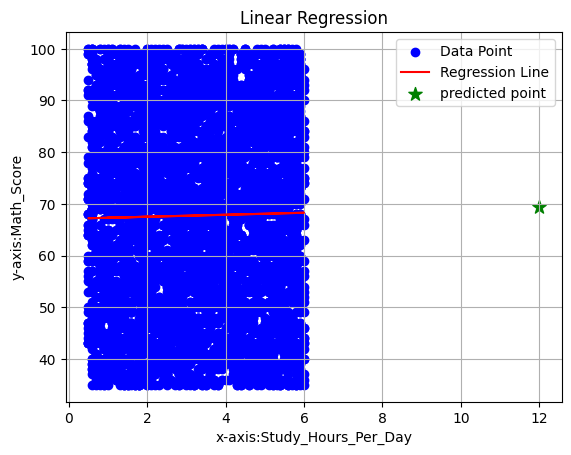

In [21]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
x=df.Study_Hours_Per_Day
y=df.Math_Score
m=LinearRegression()
m.fit(x_reshaped,y)
a=m.intercept_
b=m.coef_[0]
print("intercept=",round(a,2))
print("slope=",round(b,2))
print("Regression Equation:y={:2f}x+{:2f}".format(b,a))
temp_x=float(input("enter a new x value:"))
y_predicted_single = m.predict([[temp_x]])[0]
print("\n y_predicted =",round(y_predicted_single,2))

plt.scatter(x,y,color="blue",label="Data Point")
plt.plot(x,m.predict(x_reshaped),color="red",label="Regression Line")
plt.scatter(temp_x,y_predicted_single,color="green",s=100,marker="*",label="predicted point")
plt.xlabel("x-axis:Study_Hours_Per_Day")
plt.ylabel("y-axis:Math_Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

Intercept: 65.30118541070226
Coefficients: [0.29936679 0.02262946]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


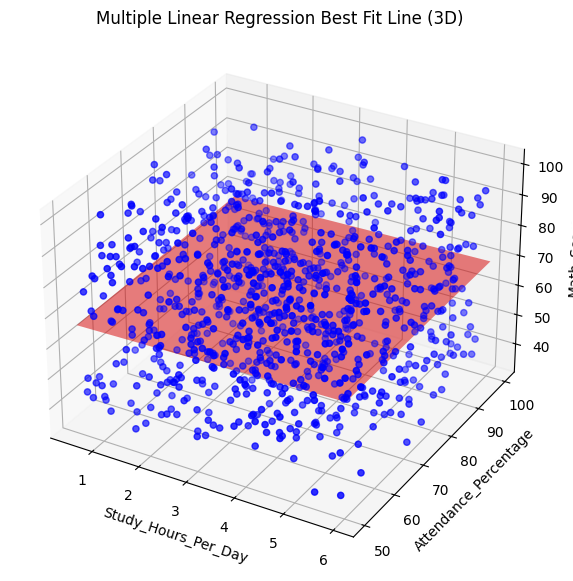

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = df[['Study_Hours_Per_Day', 'Attendance_Percentage']]
y = df.Math_Score

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['Study_Hours_Per_Day'], X_test['Attendance_Percentage'],y_test, color='blue', label='Actual Data')

x1_range = np.linspace(X_test['Study_Hours_Per_Day'].min(), X_test['Study_Hours_Per_Day'].max(), 100)
x2_range = np.linspace(X_test['Attendance_Percentage'].min(), X_test['Attendance_Percentage'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

z = model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)

ax.set_xlabel('Study_Hours_Per_Day')
ax.set_ylabel('Attendance_Percentage')
ax.set_zlabel('Math_Score')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')

plt.show()